  Product_ID  total_sales  sale_frequency   revenue  sales_variance  \
0      10002     1.092168        0.473387  0.296070       -0.045320   
1      10080    -0.346679       -0.499036 -0.359218       -0.050948   
2      10109    -0.399298       -0.590974 -0.371585       -0.051136   
3      10120    -0.285965       -0.375273 -0.358065       -0.050905   
4     10123C    -0.289484       -0.431850 -0.348942       -0.049643   

   days_since_last_sale  avg_inventory  stock_turnover  
0              0.356535       1.109106       -0.324658  
1             -0.597839      -0.331355        0.012973  
2              2.564350      -0.374675       -1.449308  
3             -0.655013      -0.328963        2.311555  
4              0.435700      -0.232357       -0.771590  
   total_sales  sale_frequency   revenue  sales_variance  \
0     1.092168        0.473387  0.296070       -0.045320   
1    -0.346679       -0.499036 -0.359218       -0.050948   
2    -0.399298       -0.590974 -0.371585       -0.0

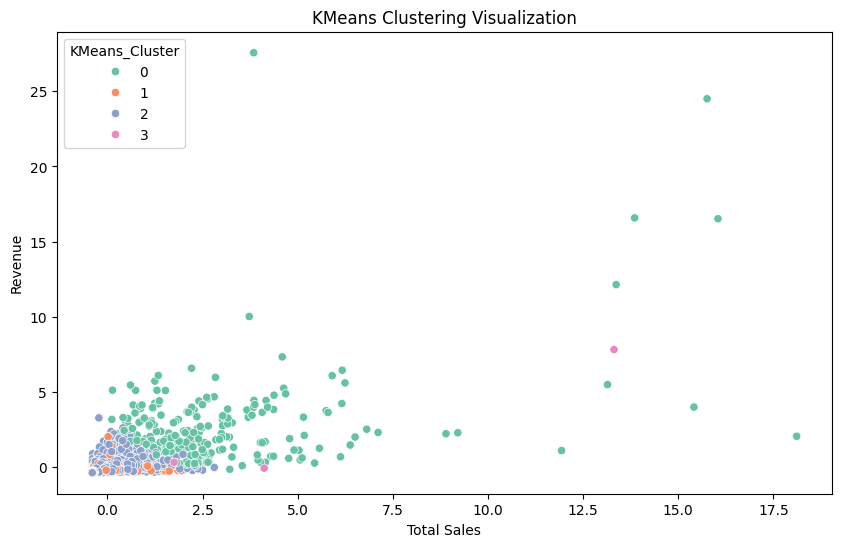

C:\Users\admin\AppData\Local\Temp\ipykernel_31516\1911335391.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


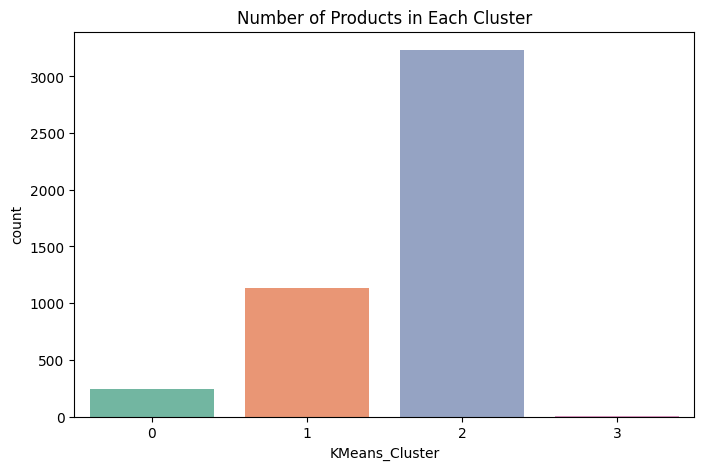

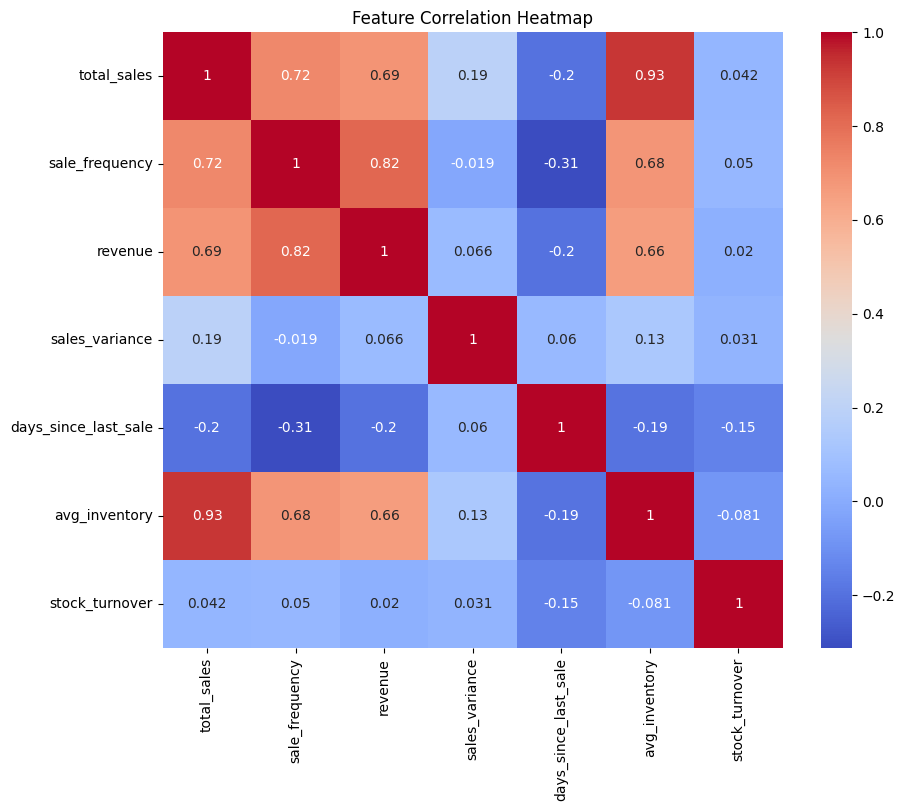

In [3]:
# =====================================================
# IMPORT THƯ VIỆN
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# =====================================================
# ĐỌC DỮ LIỆU
# =====================================================

df = pd.read_csv(
    '../data/processed/processed_retail_data.csv'
)

print(df.head())

# =====================================================
# TÁCH DỮ LIỆU CHO MODEL
# =====================================================

X = df.drop(columns=['Product_ID'])

print(X.head())

# =====================================================
# KHỞI TẠO MÔ HÌNH KMEANS
# =====================================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# =====================================================
# HUẤN LUYỆN MÔ HÌNH
# =====================================================

kmeans_labels = kmeans.fit_predict(X)

print(kmeans_labels)

# =====================================================
# GẮN NHÃN CLUSTER VÀO DATAFRAME
# =====================================================

df['KMeans_Cluster'] = kmeans_labels

# =====================================================
# HIỂN THỊ KẾT QUẢ
# =====================================================

print(df.head())

# =====================================================
# SILHOUETTE SCORE
# =====================================================

kmeans_score = silhouette_score(
    X,
    kmeans_labels
)

print("KMeans Silhouette Score:", kmeans_score)

# =====================================================
# PHÂN TÍCH TRUNG BÌNH TỪNG CLUSTER
# =====================================================

cluster_analysis = df.groupby(
    'KMeans_Cluster'
).mean(numeric_only=True)

print(cluster_analysis)

# =====================================================
# VISUALIZATION - SCATTER PLOT
# =====================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='total_sales',
    y='revenue',
    hue='KMeans_Cluster',
    palette='Set2'
)

plt.title('KMeans Clustering Visualization')
plt.xlabel('Total Sales')
plt.ylabel('Revenue')

plt.show()

# =====================================================
# BAR CHART SỐ LƯỢNG SẢN PHẨM MỖI CLUSTER
# =====================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='KMeans_Cluster',
    data=df,
    palette='Set2'
)

plt.title('Number of Products in Each Cluster')

plt.show()

# =====================================================
# HEATMAP CORRELATION
# =====================================================

plt.figure(figsize=(10,8))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Feature Correlation Heatmap')

plt.show()